In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import h_ANFIS, Hybrid_learning_algorithm, EarlyStopping, get_measures

In [2]:
import numpy as np

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [4]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.1,10000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [5]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [6]:
train_loader = data.DataLoader(
    data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), 
    batch_size = 64, 
    shuffle = True)

test_loader = data.DataLoader(
    data.TensorDataset(torch.from_numpy(scaled_test), torch.from_numpy(Y_test)), 
    batch_size = 64, 
    shuffle = False)

In [7]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

## Model & Training

In [8]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 5,
    outputs = 1,
    rule_reduced = False,
    dtype = x_train.dtype
)

In [9]:
#model.init_premises(x_train)

In [10]:
model.show_premises_structure()

        a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
MF 0  0.619671  1.919491  0.715702  0.515597  1.610092  0.304512
MF 1  0.317977  1.466292  0.907080  0.725219  1.265375  0.042440
MF 2  0.954859  1.737250 -0.233285  0.764007  1.768883  0.151861
MF 3  0.556183  1.604941  0.182739  0.250127  1.104623  0.053723
MF 4  0.276353  1.430913 -0.597890  0.198928  1.078202 -0.272382


In [11]:
model.get_premises()

tensor([[[ 0.6197,  1.9195,  0.7157],
         [ 0.3180,  1.4663,  0.9071],
         [ 0.9549,  1.7372, -0.2333],
         [ 0.5562,  1.6049,  0.1827],
         [ 0.2764,  1.4309, -0.5979]],

        [[ 0.5156,  1.6101,  0.3045],
         [ 0.7252,  1.2654,  0.0424],
         [ 0.7640,  1.7689,  0.1519],
         [ 0.2501,  1.1046,  0.0537],
         [ 0.1989,  1.0782, -0.2724]]], dtype=torch.float64)

In [12]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = EarlyStopping(patience=10, delta=0.01)

trainer = Hybrid_learning_algorithm(
    epochs=200,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.4,
    early_stopping=early_stopping
)

In [13]:
trainer(model, train_loader, verbose=True)

Epoch:   1/200 - loss: 0.051512 - validation loss: 0.052642
Epoch:   2/200 - loss: 0.050658 - validation loss: 0.051782
Epoch:   3/200 - loss: 0.048873 - validation loss: 0.050096
Epoch:   4/200 - loss: 0.048482 - validation loss: 0.049989
Epoch:   5/200 - loss: 0.047365 - validation loss: 0.048870
Epoch:   6/200 - loss: 0.046153 - validation loss: 0.047677
Epoch:   7/200 - loss: 0.046754 - validation loss: 0.047692
Epoch:   8/200 - loss: 0.044328 - validation loss: 0.045800
Epoch:   9/200 - loss: 0.044489 - validation loss: 0.046441
Epoch:  10/200 - loss: 0.043919 - validation loss: 0.045130
Early stopping
Training finished


In [14]:
model.show_premises_structure()

        a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
MF 0  0.612939  1.911731  0.716405  0.516408  1.610441  0.300605
MF 1  0.334618  1.463191  0.900773  0.728824  1.268300  0.045401
MF 2  0.955999  1.721890 -0.240047  0.762243  1.775104  0.151292
MF 3  0.554790  1.608525  0.180896  0.251251  1.106180  0.063845
MF 4  0.292830  1.453339 -0.586355  0.196062  1.074983 -0.276851


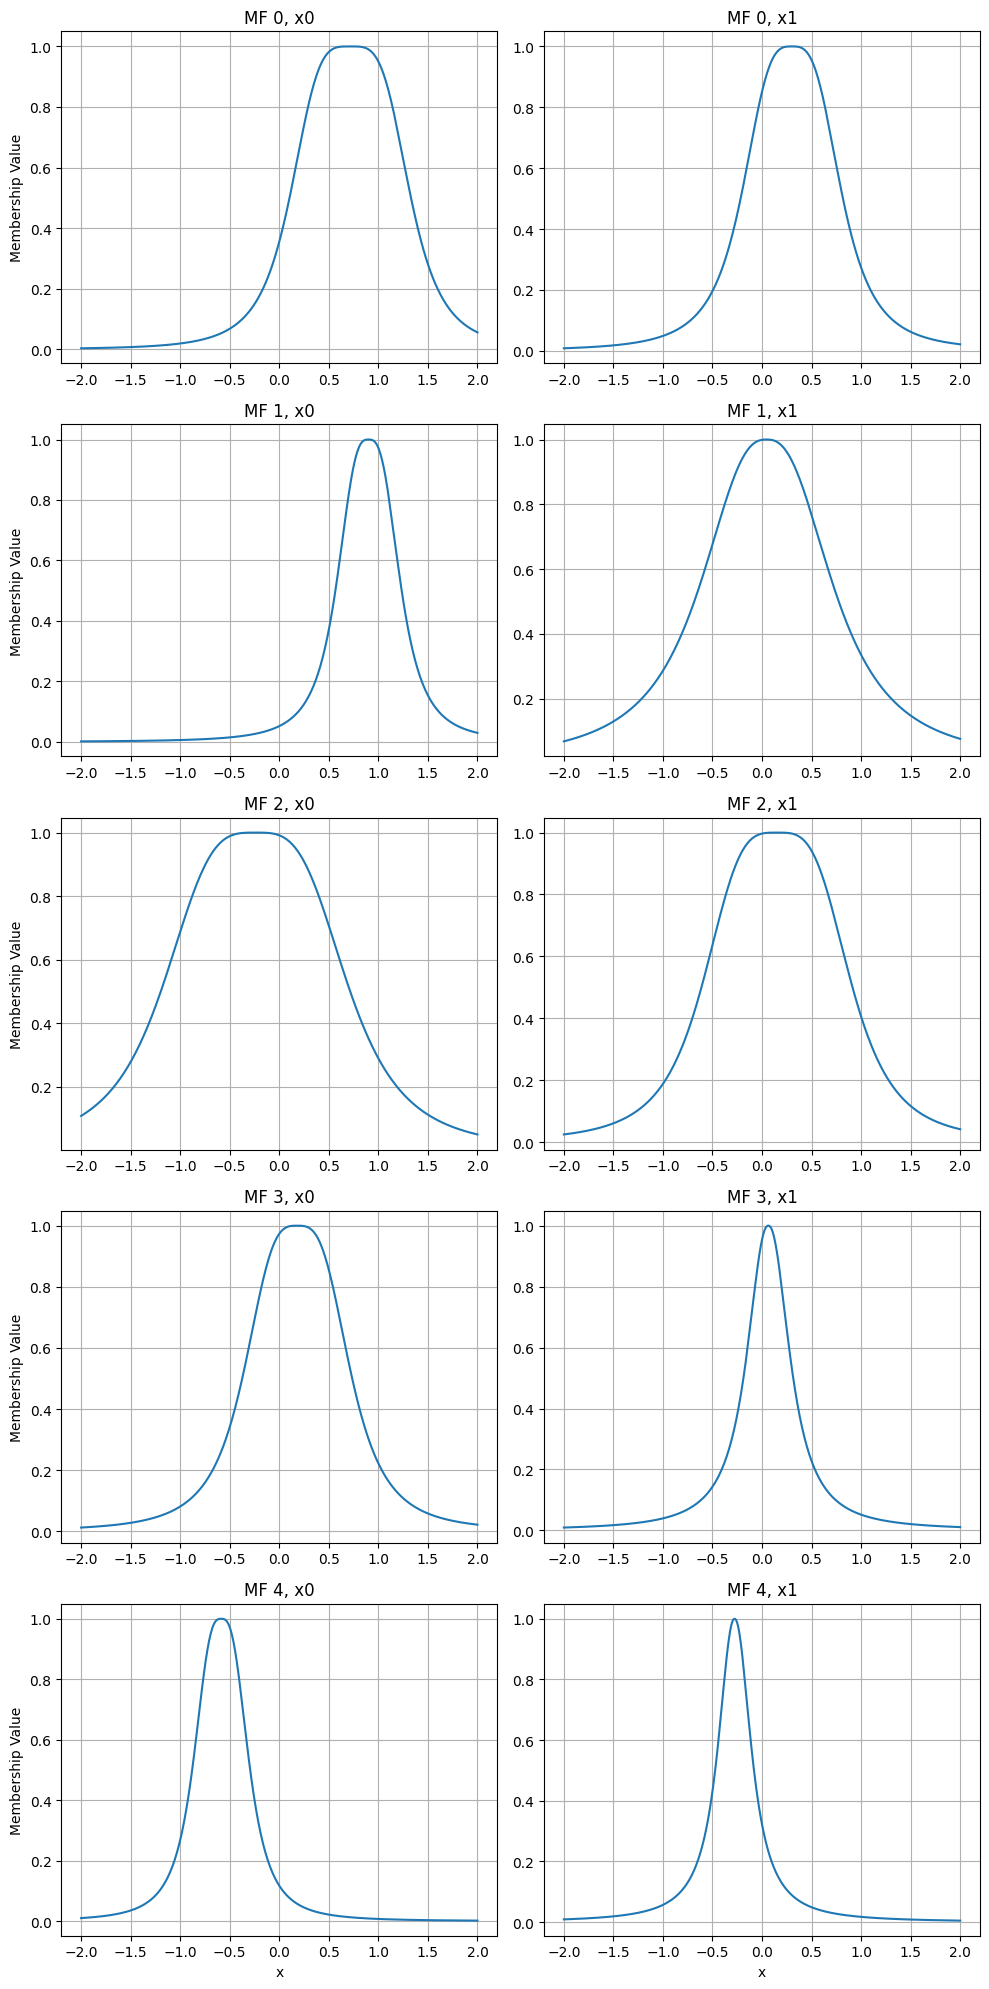

In [15]:
model.plot_premises()

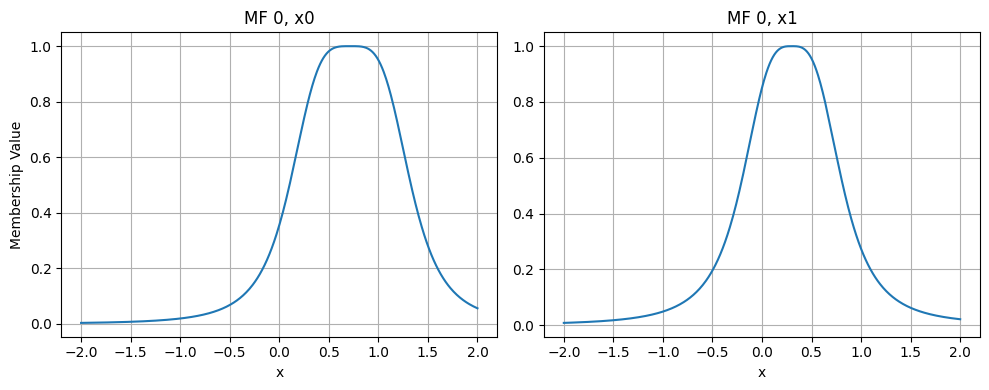

In [16]:
model.plot_premises(mf = 0)

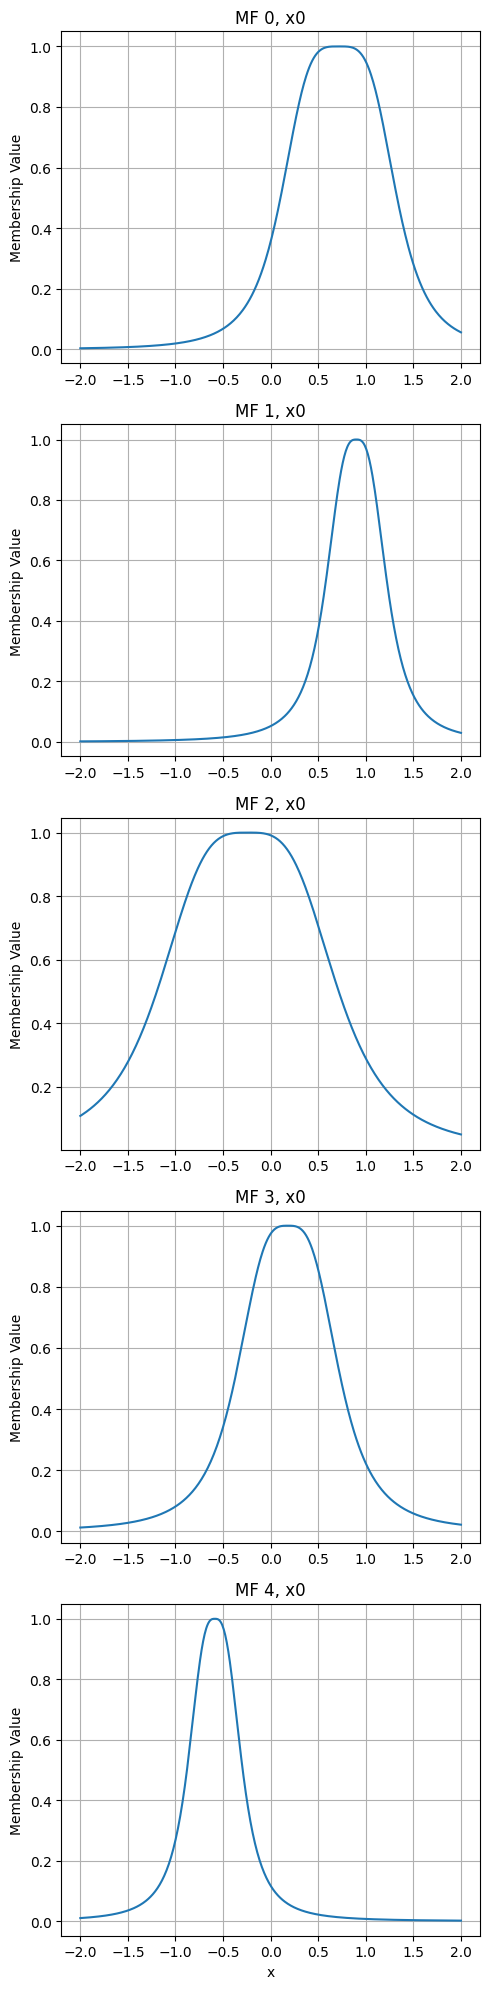

In [17]:
model.plot_premises(input_dim=0)

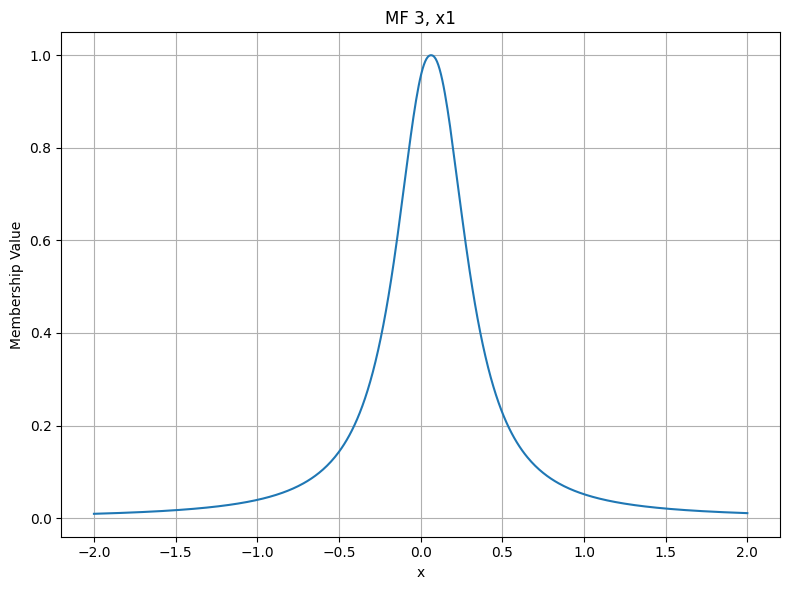

In [18]:
model.plot_premises(mf=3, input_dim=1)

In [19]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.612939,1.911731,0.716405,0.516408,1.610441,0.300605
MF 1,0.334618,1.463191,0.900773,0.728824,1.268300,0.045401
MF 2,0.955999,1.721890,-0.240047,0.762243,1.775104,0.151292
MF 3,0.554790,1.608525,0.180896,0.251251,1.106180,0.063845
MF 4,0.292830,1.453339,-0.586355,0.196062,1.074983,-0.276851


In [20]:
x_test = test_loader.dataset.tensors[0]
y_test = test_loader.dataset.tensors[1]

test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.06520559750521986
RMSE: 0.25535386722197856
MAE: 0.1804018543027792
R2: 0.9822963324247207
MAPE: 30.80621137483648


In [21]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.0717048092479467
RMSE: 0.26777753686212497
MAE: 0.19743875728529003
R2: 0.9792743446567904
MAPE: 4.870245115397158


In [22]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.612939,1.911731,0.716405,0.516408,1.610441,0.300605
MF 1,0.334618,1.463191,0.900773,0.728824,1.268300,0.045401
MF 2,0.955999,1.721890,-0.240047,0.762243,1.775104,0.151292
MF 3,0.554790,1.608525,0.180896,0.251251,1.106180,0.063845
MF 4,0.292830,1.453339,-0.586355,0.196062,1.074983,-0.276851


In [23]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,-245.481862,-481.590732,-799.505518
rule 2,-215.049509,-363.159078,-985.140273
rule 3,320.757554,405.933746,1370.069417
rule 4,169.745744,639.892539,729.335615
rule 5,110.192922,55.803572,88.037515
rule 6,953.975849,226.533867,-359.312306
rule 7,797.481229,197.252952,-181.710768
rule 8,-1188.904034,-201.383123,276.542183
rule 9,-811.767100,-362.414552,407.076222
rule 10,-226.250379,-96.027255,121.250395
